## 0. Setup

In [1]:
# Run this once per Colab session.
!pip install -q tensorflow opencv-python-headless matplotlib seaborn scikit-learn pandas streamlit gradio pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 122.1 MB/s eta 0:00:00


In [2]:
# CELL 1: SIMPLE FIX
!pip install --force-reinstall numpy==1.23.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 79.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [3]:
# CELL 2: IMPORTS AFTER RESTART
import os, io, shutil, zipfile, random, pathlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Done!")

✅ Done!


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Set the path to your zip file on Drive


In [7]:
ZIP_PATH = "/content/drive/MyDrive/Dataset/Random Background.zip"  # <-- EDIT THIS PATH

assert os.path.exists(ZIP_PATH), (
    f"Could not find {ZIP_PATH}. Update ZIP_PATH to the correct location of "
    f"Random_Background.zip inside your Google Drive."
)
print("Found zip:", ZIP_PATH, "-", round(os.path.getsize(ZIP_PATH)/1e6, 1), "MB")


Found zip: /content/drive/MyDrive/Dataset/Random Background.zip - 467.8 MB


## 1. Assumptions & things to confirm with your team


In [8]:
# Folder index -> (Devanagari letter, romanisation)
# Standard 36-consonant Devanagari order used for Nepali Sign Language alphabets.
CLASS_NAMES = {
    0:  "क (ka)",   1:  "ख (kha)",  2:  "ग (ga)",   3:  "घ (gha)",
    4:  "ङ (nga)",  5:  "च (cha)",  6:  "छ (chha)", 7:  "ज (ja)",
    8:  "झ (jha)",  9:  "ञ (nya)",  10: "ट (Ta)",   11: "ठ (Tha)",
    12: "ड (Da)",   13: "ढ (Dha)",  14: "ण (Na)",   15: "त (ta)",
    16: "थ (tha)",  17: "द (da)",   18: "ध (dha)",  19: "न (na)",
    20: "प (pa)",   21: "फ (pha)",  22: "ब (ba)",   23: "भ (bha)",
    24: "म (ma)",   25: "य (ya)",   26: "र (ra)",   27: "ल (la)",
    28: "व (wa)",   29: "श (sha)",  30: "ष (Sha)",  31: "स (sa)",
    32: "ह (ha)",   33: "क्ष (ksha)", 34: "त्र (tra)", 35: "ज्ञ (gya)",
}
NUM_CLASSES = len(CLASS_NAMES)
assert NUM_CLASSES == 36
print(f"{NUM_CLASSES} classes loaded.")


36 classes loaded.


## 2. Extract the dataset cleanly

In [9]:
EXTRACT_DIR = "/content/nsl_data"
RAW_DIR = os.path.join(EXTRACT_DIR, "Random Background")

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

def is_wanted(zip_info_name: str) -> bool:
    '''Keep only real image files that live directly inside a numeric
    class folder under 'Random Background/'.'''
    parts = zip_info_name.split("/")
    if parts[0] != "Random Background":
        return False                      # skip __MACOSX and anything else
    if len(parts) != 3:
        return False                      # skip the bare folder entries
    class_folder, filename = parts[1], parts[2]
    if not class_folder.isdigit():
        return False                      # skip non-numeric folders, if any
    if filename.startswith("._") or filename == ".DS_Store":
        return False                      # skip macOS metadata files
    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        return False
    return True

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    members = [m for m in zf.namelist() if is_wanted(m)]
    print(f"Extracting {len(members)} image files (metadata/junk files skipped)...")
    zf.extractall(EXTRACT_DIR, members=members)

print("Done. Example extracted paths:")
for p in members[:3]:
    print(" -", p)


Extracting 18000 image files (metadata/junk files skipped)...
Done. Example extracted paths:
 - Random Background/32/63.jpg
 - Random Background/32/189.jpg
 - Random Background/32/77.jpg


## 3. Build a clean file index and verify every image

In [10]:
records = []
for class_folder in sorted(os.listdir(RAW_DIR), key=lambda x: int(x) if x.isdigit() else -1):
    class_dir = os.path.join(RAW_DIR, class_folder)
    if not (os.path.isdir(class_dir) and class_folder.isdigit()):
        continue
    label_idx = int(class_folder)
    for fname in os.listdir(class_dir):
        if fname.startswith("._") or fname == ".DS_Store":
            continue
        records.append({
            "filepath": os.path.join(class_dir, fname),
            "label_idx": label_idx,
            "label_name": CLASS_NAMES.get(label_idx, str(label_idx)),
        })

df = pd.DataFrame(records)
print("Total images found:", len(df))
print("Classes found:", df.label_idx.nunique())
df.head()


Total images found: 18000
Classes found: 36


,filepath,label_idx,label_name
0,/content/nsl_data/Random Background/0/248.jpg,0,क (ka)
1,/content/nsl_data/Random Background/0/101.jpg,0,क (ka)
2,/content/nsl_data/Random Background/0/47.jpg,0,क (ka)
3,/content/nsl_data/Random Background/0/322.jpg,0,क (ka)
4,/content/nsl_data/Random Background/0/258.jpg,0,क (ka)


In [11]:
# Verify every image actually opens (catches truncated/corrupt files
# before they crash training, rather than mid-epoch).
def verify_image(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

print("Verifying images (this scans all files once, ~1-2 min for 18k images)...")
df["is_valid"] = df["filepath"].apply(verify_image)
n_bad = (~df["is_valid"]).sum()
print(f"Corrupt/unreadable images found: {n_bad}")
if n_bad:
    print(df.loc[~df.is_valid, "filepath"].tolist()[:10])
df = df[df.is_valid].drop(columns="is_valid").reset_index(drop=True)
print("Usable images after verification:", len(df))


Verifying images (this scans all files once, ~1-2 min for 18k images)...
Corrupt/unreadable images found: 0
Usable images after verification: 18000


## 4. Exploratory Data Analysis (EDA)

/tmp/ipykernel_385/1685424009.py:7: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1685424009.py:7: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_385/1685424009.py:7: UserWarning: Glyph 2326 (\N{DEVANAGARI LETTER KHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1685424009.py:7: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1685424009.py:7: UserWarning: Glyph 2328 (\N{DEVANAGARI LETTER GHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1685424009.py:7: UserWarning: Glyph 2329 (\N{DEVANAGARI LETTER NGA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1685424009.py:7: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3

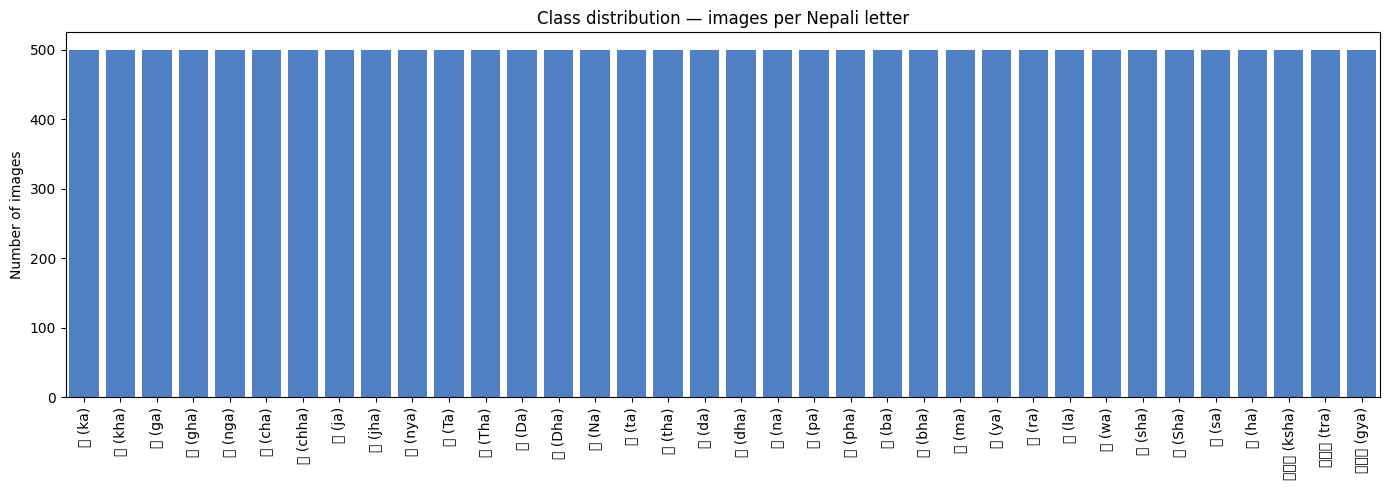

Min / max / mean images per class: 500 / 500 / 500.0
Balanced dataset: True


In [12]:
plt.figure(figsize=(14, 5))
counts = df.label_idx.value_counts().sort_index()
sns.barplot(x=[CLASS_NAMES[i] for i in counts.index], y=counts.values, color="#3b7dd8")
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.title("Class distribution — images per Nepali letter")
plt.tight_layout()
plt.show()

print("Min / max / mean images per class:",
      counts.min(), "/", counts.max(), "/", round(counts.mean(), 1))
print("Balanced dataset:", counts.min() == counts.max())


/tmp/ipykernel_385/1883136299.py:11: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1883136299.py:11: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_385/1883136299.py:11: UserWarning: Glyph 2326 (\N{DEVANAGARI LETTER KHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1883136299.py:11: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1883136299.py:11: UserWarning: Glyph 2328 (\N{DEVANAGARI LETTER GHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1883136299.py:11: UserWarning: Glyph 2329 (\N{DEVANAGARI LETTER NGA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_385/1883136299.py:11: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyk

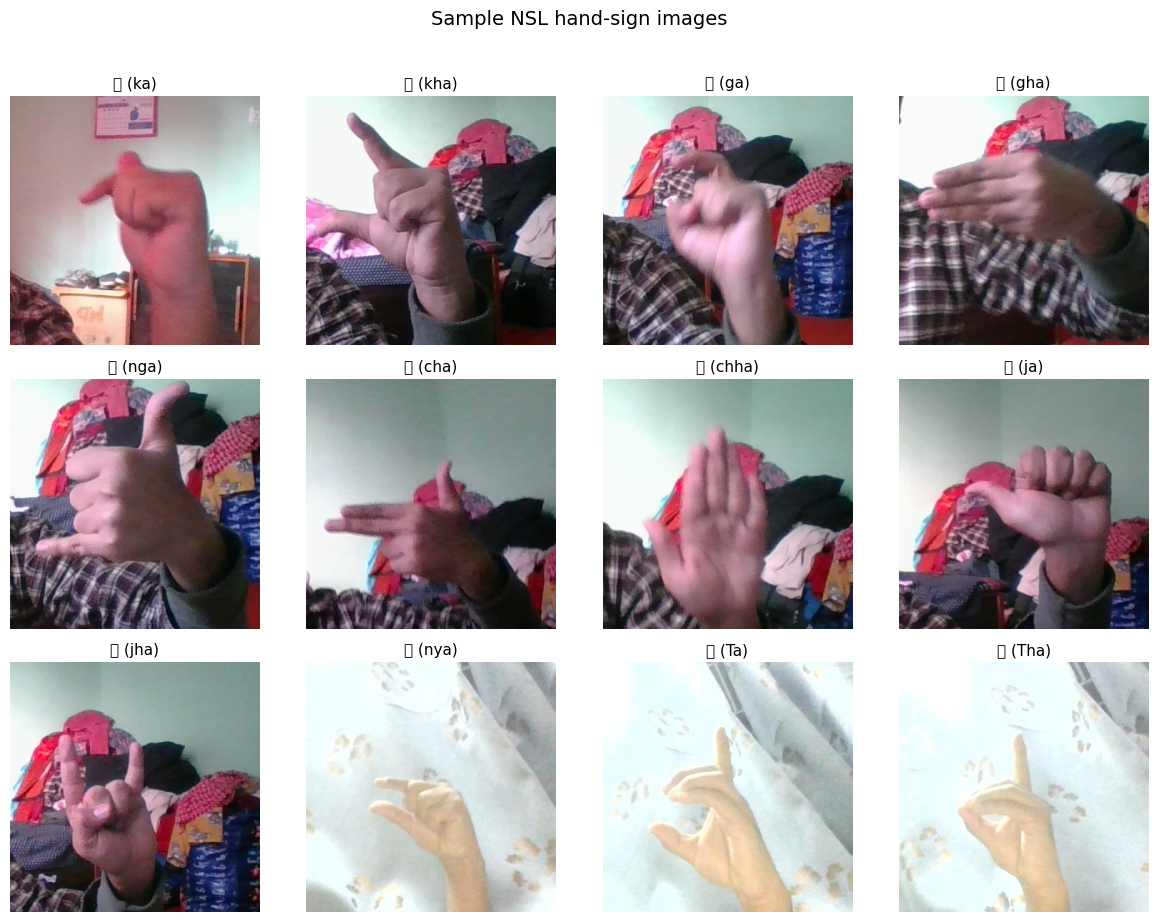

In [13]:
# Sample grid: a few random signs from different letters
sample_classes = sorted(df.label_idx.unique())[:12]
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, cls in zip(axes.flat, sample_classes):
    row = df[df.label_idx == cls].sample(1, random_state=SEED).iloc[0]
    img = Image.open(row.filepath)
    ax.imshow(img)
    ax.set_title(row.label_name, fontsize=11)
    ax.axis("off")
plt.suptitle("Sample NSL hand-sign images", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
# Basic image property check (size / mode) — informs preprocessing choices.
sizes = df.filepath.sample(200, random_state=SEED).apply(lambda p: Image.open(p).size)
print("Unique sizes among 200 sampled images:", set(sizes))


Unique sizes among 200 sampled images: {(300, 300)}


## 5. Stratified 70 / 15 / 15 split

Split is done **per class** (stratified) so every letter is proportionally
represented in train, validation, and test — important with 36 classes to
avoid a class accidentally being under-represented in the test set.


In [15]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df.label_idx, random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df.label_idx, random_state=SEED
)

print(f"Train: {len(train_df)}  ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df)}  ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df)}  ({len(test_df)/len(df):.1%})")

# Sanity check: no file leaks across splits
train_set, val_set, test_set = set(train_df.filepath), set(val_df.filepath), set(test_df.filepath)
assert not (train_set & val_set) and not (train_set & test_set) and not (val_set & test_set)
print("No overlap between splits — confirmed.")


Train: 12600  (70.0%)
Val:   2700  (15.0%)
Test:  2700  (15.0%)
No overlap between splits — confirmed.


## 6. `tf.data` pipeline (loading, resizing, normalisation, augmentation)

In [16]:
IMG_SIZE = 160          # compatible with MobileNetV2's alpha/input-size options
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(dataframe, training: bool):
    filepaths = dataframe.filepath.values
    labels = dataframe.label_idx.values
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# Augmentation is applied as part of the model (train-time only, via `training=True`)
# so the *same* saved model can be used directly for inference without extra code.
# NOTE: no horizontal flip — see Section 1 (flipping changes sign meaning).
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.10),
], name="augmentation")


## 7. Model A — Baseline CNN (built from scratch)

Uses **Batch Normalisation** and **Dropout** as regularisers (satisfies the
"≥2 optimisation/regularisation techniques" requirement on its own; combined
with augmentation and early-stopping/LR-scheduling below there are more than
two applied across the pipeline).


In [17]:
def build_baseline_cnn(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="baseline_cnn")

baseline_model = build_baseline_cnn()
baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 464,900 (1.77 MB)

 Trainable params: 463,940 (1.77 MB)

 Non-trainable params: 960 (3.75 KB)

## 8. Model B — Transfer Learning (MobileNetV2, fine-tuned)

MobileNetV2 pretrained on ImageNet is used as a feature extractor, then the
top layers are unfrozen and fine-tuned at a low learning rate — the
recommended two-stage transfer-learning recipe. MobileNetV2 is a good fit for
this project's deployment story (Section 8 of the report — running on
low-resource/edge/mobile devices in Nepal).


In [ ]:
def build_transfer_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = data_augmentation(inputs)
    # MobileNetV2 expects [-1, 1]; our pipeline already produced [0, 1], so rescale.
    x = layers.Rescaling(2.0, offset=-1.0)(x)

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False  # Stage 1: frozen backbone

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="mobilenetv2_transfer")
    return model, base_model

transfer_model, transfer_base = build_transfer_model()
transfer_model.summary()


## 9. Training setup (callbacks = early stopping + LR scheduling)

In [ ]:
def make_callbacks(checkpoint_path):
    return [
        callbacks.EarlyStopping(monitor="val_accuracy", patience=6,
                                 restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                     patience=3, min_lr=1e-6),
        callbacks.ModelCheckpoint(checkpoint_path, monitor="val_accuracy",
                                   save_best_only=True),
    ]

os.makedirs("/content/checkpoints", exist_ok=True)
EPOCHS_BASELINE = 25
EPOCHS_TRANSFER_HEAD = 10
EPOCHS_TRANSFER_FINETUNE = 15


In [ ]:
# --- Train Model A: baseline CNN ---
baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    callbacks=make_callbacks("/content/checkpoints/baseline_best.keras"),
)


In [ ]:
# --- Train Model B, stage 1: frozen backbone (train the new head only) ---
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_transfer_head = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER_HEAD,
    callbacks=make_callbacks("/content/checkpoints/transfer_head_best.keras"),
)


In [ ]:
# --- Train Model B, stage 2: unfreeze top of backbone and fine-tune ---
transfer_base.trainable = True
# Keep early layers frozen (generic features); fine-tune only the deeper layers.
FINE_TUNE_AT = len(transfer_base.layers) - 40
for layer in transfer_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # low LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_transfer_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER_HEAD + EPOCHS_TRANSFER_FINETUNE,
    initial_epoch=history_transfer_head.epoch[-1] + 1,
    callbacks=make_callbacks("/content/checkpoints/transfer_finetuned_best.keras"),
)


## 10. Training curves

In [ ]:
def plot_history(histories, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for h, lbl in zip(histories, labels):
        axes[0].plot(h.history["accuracy"], label=f"{lbl} - train")
        axes[0].plot(h.history["val_accuracy"], linestyle="--", label=f"{lbl} - val")
        axes[1].plot(h.history["loss"], label=f"{lbl} - train")
        axes[1].plot(h.history["val_loss"], linestyle="--", label=f"{lbl} - val")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history([history_baseline], ["Baseline CNN"], "Model A — Baseline CNN")

# Concatenate the two transfer-learning stages into one continuous curve
combined_transfer_history = type("H", (), {"history": {
    k: history_transfer_head.history[k] + history_transfer_finetune.history[k]
    for k in history_transfer_head.history
}})()
plot_history([combined_transfer_history], ["MobileNetV2 transfer"],
             "Model B — Transfer Learning (frozen head -> fine-tuned)")


## 11. Evaluation on the held-out TEST set

In [ ]:
def evaluate_model(model, test_ds, test_df, model_name):
    y_true = test_df.label_idx.values
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"\n===== {model_name} — Test accuracy: {acc:.4f} =====\n")

    target_names = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]
    report = classification_report(
        y_true, y_pred, target_names=target_names, digits=3, zero_division=0
    )
    print(report)
    return y_true, y_pred, acc, report

y_true_base, y_pred_base, acc_base, report_base = evaluate_model(
    baseline_model, test_ds, test_df, "Model A - Baseline CNN"
)
y_true_tr, y_pred_tr, acc_tr, report_tr = evaluate_model(
    transfer_model, test_ds, test_df, "Model B - MobileNetV2 Transfer Learning"
)


In [ ]:
def plot_confusion(y_true, y_pred, title, figsize=(14, 12)):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(CLASS_NAMES))
    labels_short = [CLASS_NAMES[i].split(" ")[0] for i in sorted(CLASS_NAMES)]
    plt.figure(figsize=figsize)
    sns.heatmap(cm, cmap="Blues", xticklabels=labels_short, yticklabels=labels_short)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.tight_layout()
    plt.show()
    return cm

cm_base = plot_confusion(y_true_base, y_pred_base, "Confusion Matrix — Baseline CNN")
cm_tr = plot_confusion(y_true_tr, y_pred_tr, "Confusion Matrix — MobileNetV2 Transfer")


In [ ]:
# Per-class accuracy comparison (helps write the Ethics section: which
# letters/users does the current model serve worst?)
def per_class_accuracy(cm):
    return cm.diagonal() / cm.sum(axis=1)

pc_base = per_class_accuracy(cm_base)
pc_tr = per_class_accuracy(cm_tr)

compare_df = pd.DataFrame({
    "letter": [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
    "baseline_cnn_acc": pc_base,
    "mobilenetv2_transfer_acc": pc_tr,
}).sort_values("mobilenetv2_transfer_acc")

print("Overall test accuracy — Baseline CNN: %.4f | MobileNetV2 Transfer: %.4f"
      % (acc_base, acc_tr))
compare_df


## 12. Error analysis — inspect misclassified examples

In [ ]:
def show_misclassified(model, test_df, n=12, model_name=""):
    wrong_examples = []
    for _, row in test_df.sample(frac=1, random_state=SEED).iterrows():
        img = Image.open(row.filepath).resize((IMG_SIZE, IMG_SIZE)).convert("RGB")
        arr = np.array(img, dtype=np.float32) / 255.0
        pred = model.predict(arr[np.newaxis, ...], verbose=0)
        pred_idx = int(np.argmax(pred))
        if pred_idx != row.label_idx:
            wrong_examples.append((row.filepath, row.label_idx, pred_idx, img))
        if len(wrong_examples) == n:
            break

    if not wrong_examples:
        print(f"No misclassifications found in this scan for {model_name}.")
        return

    fig, axes = plt.subplots(3, 4, figsize=(13, 10))
    for ax, (fp, true_idx, pred_idx, img) in zip(axes.flat, wrong_examples):
        ax.imshow(img)
        ax.set_title(f"True: {CLASS_NAMES[true_idx]}\nPred: {CLASS_NAMES[pred_idx]}",
                     fontsize=9, color="crimson")
        ax.axis("off")
    plt.suptitle(f"Misclassified examples — {model_name}", y=1.02)
    plt.tight_layout()
    plt.show()

show_misclassified(transfer_model, test_df, n=12, model_name="MobileNetV2 Transfer")


## 13. Model comparison summary

Use this table directly in the report's *Experiments & Results* and
*Comparison & Ablation* sections.


In [ ]:
summary = pd.DataFrame([
    {
        "Model": "Baseline CNN (from scratch)",
        "Params": baseline_model.count_params(),
        "Test Accuracy": round(acc_base, 4),
        "Regularisation used": "BatchNorm, Dropout, Augmentation, EarlyStopping, ReduceLROnPlateau",
    },
    {
        "Model": "MobileNetV2 (transfer learning, fine-tuned)",
        "Params": transfer_model.count_params(),
        "Test Accuracy": round(acc_tr, 4),
        "Regularisation used": "Dropout, Augmentation, EarlyStopping, ReduceLROnPlateau, 2-stage fine-tuning",
    },
])
summary


## 14. Save the best model (and class mapping) to Google Drive

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/NSL_Project/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Pick whichever model scored higher on the test set as the deployed model.
best_model, best_name = (transfer_model, "mobilenetv2_transfer") if acc_tr >= acc_base \
    else (baseline_model, "baseline_cnn")

best_model_path = os.path.join(SAVE_DIR, f"{best_name}.keras")
best_model.save(best_model_path)

with open(os.path.join(SAVE_DIR, "class_names.json"), "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)

print(f"Saved best model ('{best_name}', test acc={max(acc_tr, acc_base):.4f}) to:\n{best_model_path}")


## 15. Inference — always returns the **Nepali letter**, never the raw class index

In [ ]:
def predict_sign(image_path_or_pil, model=best_model, top_k=3):
    '''Predict the Nepali Sign Language letter for a single image.

    Returns a list of (letter_name, confidence) tuples, most confident first.
    Intentionally never surfaces the raw numeric folder index to the caller —
    only the human-readable Nepali letter is returned.
    '''
    if isinstance(image_path_or_pil, str):
        img = Image.open(image_path_or_pil).convert("RGB")
    else:
        img = image_path_or_pil.convert("RGB")

    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img_resized, dtype=np.float32) / 255.0
    preds = model.predict(arr[np.newaxis, ...], verbose=0)[0]

    top_idx = np.argsort(preds)[::-1][:top_k]
    return [(CLASS_NAMES[int(i)], float(preds[i])) for i in top_idx]

# quick smoke test on a random test-set image
sample_row = test_df.sample(1, random_state=SEED).iloc[0]
result = predict_sign(sample_row.filepath)
print("True letter:", sample_row.label_name)
print("Top predictions:", result)


## 16. Lightweight demo interface (Gradio)

Fulfils the "demo interface a non-technical user could try" requirement. Run
the cell — Colab will print a public shareable link.


In [ ]:
import gradio as gr

def gradio_predict(image):
    if image is None:
        return {}
    results = predict_sign(image, model=best_model, top_k=5)
    return {label: float(conf) for label, conf in results}

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Upload or capture a hand-sign photo"),
    outputs=gr.Label(num_top_classes=5, label="Predicted Nepali letter"),
    title="Nepali Sign Language Alphabet Recognition",
    description=(
        "Upload a photo of a hand sign for a Nepali consonant letter. "
        "The model returns its top-5 predicted letters with confidence scores. "
        "Built for the 'AI for the Himalayas 2026' hackathon prototype (Track T3)."
    ),
    examples=[test_df.sample(1, random_state=i).iloc[0].filepath for i in range(4)],
)

demo.launch(share=True, debug=False)


## 17. Next steps for your team (not code — for the report/repo)

This notebook satisfies the **technical** parts of Task 3. Still needed for
full marks per the rubric:

- **GitHub repo structure**: split this notebook's sections into
  `/data`, `/notebooks`, `/src`, `/models`, `/results`, `/docs` with a clear
  `README.md`, and make sure **every team member has commits**.
- **Report (Task 4)**: Executive Summary, Literature Review (5+ peer-reviewed
  sources), Ethical/Social/Environmental Impact (≥800 words — use the
  per-class accuracy table and confusion matrix above as evidence for the
  bias/false-positive-vs-negative discussion), Deployment Considerations
  (MobileNetV2 was chosen partly because it is small enough for
  low-connectivity/low-compute deployment — make that argument explicitly),
  Team Reflection (TGC 4).
- **Consent & data ethics**: Track T3 requires consent for any photos of
  people. Confirm and document how consent was obtained for this dataset.
- **AI Tool Usage Declaration**: this notebook was drafted with AI
  assistance (per the assignment's Section 10.1) — disclose that in your
  report's appendix as required.
